In [22]:
import json
import os
try:
    from backend.utils import load_json
except ModuleNotFoundError:
    print("Updating working directory....")
    os.chdir("../")
    print(os.getcwd())
    from backend.utils import load_json

from backend.utils import load_response_dict
from backend.nli_labels import ExNLILabel

In [2]:
from backend.dataset_utils import organize_dataset, retrieve_annotation
test_dataset = "data/test.json"
dataset = load_json(test_dataset)
dataset = organize_dataset(dataset)

In [ ]:
responses0 = load_response_dict("out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed0")
responses1 = load_response_dict("out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed1")
responses42 = load_response_dict("out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed42")

Loading responses: 100%|██████████| 123/123 [00:00<00:00, 8187.06it/s]


In [ ]:
correct = []
wrong = []

for doc_id, doc_dict in responses.items():
    hypotheses = list(doc_dict["annotation_sets"][0]["annotations"].keys())
    for hypo_id in hypotheses:
        pred = retrieve_annotation(responses, doc_id, hypo_id)
        class_probs = pred["class_probs"]
        choice = max(class_probs, key=class_probs.get)
        choice_prob = class_probs[choice]

        gt = retrieve_annotation(dataset, doc_id, hypo_id)

        if choice == gt["choice"]:
            correct.append(choice_prob)
        else:
            wrong.append(choice_prob)



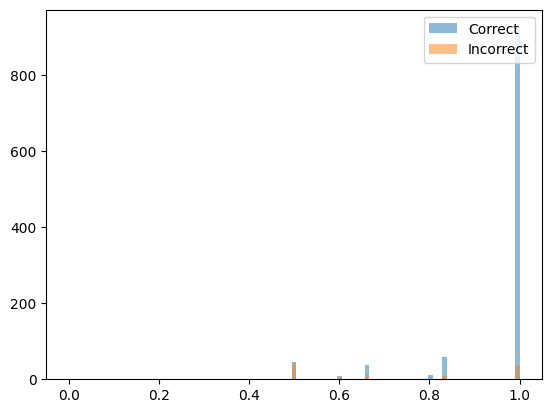

In [41]:

import numpy
from matplotlib import pyplot


bins = numpy.linspace(0, 1, num=100)

pyplot.hist(correct, bins, alpha=0.5, label='Correct')
pyplot.hist(wrong, bins, alpha=0.5, label='Incorrect')
pyplot.legend(loc='upper right')
pyplot.show()